In [ ]:
import pandas as pd
import numpy as np
import sys
import joblib
from pathlib import Path


from cuml.linear_model import LogisticRegression as CUML_LogisticRegression

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
OUT_DIR = ""

MODEL_OUT = "binary_logistic.joblib"


train_bc = pd.read_parquet('train_bc.parquet')
test_bc = pd.read_parquet('test_bc.parquet')

X_train = train_bc.drop('Attack', axis=1)
y_train = train_bc['Attack']
X_test = test_bc.drop('Attack', axis=1)
y_test = test_bc['Attack']

print(f"Train data loaded (GPU): {len(X_train)} samples.")
print(f"Test data loaded (GPU): {len(X_test)} samples.")
print("-" * 30)

Train data loaded (GPU): 509488 samples.
Test data loaded (GPU): 371272 samples.
------------------------------


In [ ]:

pipe = Pipeline([
    ('logreg', CUML_LogisticRegression( 
        max_iter=5000,
    ))
])
param_grid = [
    {
        'logreg__solver': ['liblinear', 'saga'],
        'logreg__penalty': ['l1', 'l2'],
        'logreg__C': np.logspace(-3, 3, 7)
    },
    {
        'logreg__solver': ['lbfgs', 'sag'],
        'logreg__penalty': ['l2'],
        'logreg__C': np.logspace(-3, 3, 7)
    }
]

In [ ]:
grid_search = GridSearchCV(
    pipe,
    param_grid,
    cv=5,
    scoring='f1_macro',
    verbose=0,
    n_jobs=1 
)

total_combinations = len(param_grid[0]['logreg__C']) * (len(param_grid[0]['logreg__solver']) * len(param_grid[0]['logreg__penalty'])) + \
                     len(param_grid[1]['logreg__C']) * (len(param_grid[1]['logreg__solver']) * len(param_grid[1]['logreg__penalty']))

print(f"Starting GPU-accelerated Grid Search across {total_combinations} total parameter combinations...")
grid_search.fit(X_train, y_train)
print("Grid Search complete.")

Starting GPU-accelerated Grid Search across 42 total parameter combinations...


INFO:distributed.core:Event loop was unresponsive in Scheduler for 13.91s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 13.92s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 14.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 14.06s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 8.93s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. Th

[2025-11-28 12:42:55.749] [CUML] [warning] QWL-QN: max iterations reached
[2025-11-28 12:42:55.752] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


INFO:distributed.core:Event loop was unresponsive in Scheduler for 7.97s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 7.97s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 9.60s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 9.60s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 4.15s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This c

[2025-11-28 12:43:44.708] [CUML] [warning] QWL-QN: max iterations reached
[2025-11-28 12:43:44.710] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


...

[2025-11-28 12:51:40.105] [CUML] [warning] QWL-QN: max iterations reached
[2025-11-28 12:51:40.108] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


INFO:distributed.core:Event loop was unresponsive in Scheduler for 19.63s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 19.64s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.


[2025-11-28 12:51:59.881] [CUML] [warning] QWL-QN: max iterations reached
[2025-11-28 12:51:59.882] [CUML] [warning] Maximum iterations reached before solver is converged. To increase model accuracy you can increase the number of iterations (max_iter) or improve the scaling of the input data.


INFO:distributed.core:Event loop was unresponsive in Scheduler for 9.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 9.09s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.65s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.66s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This can cause timeouts and instability.
INFO:distributed.core:Event loop was unresponsive in Scheduler for 3.96s.  This is often caused by long-running GIL-holding functions or moving large chunks of data. This c

Grid Search complete.


In [ ]:

best_logreg = grid_search.best_estimator_
best_params = grid_search.best_params_
best_score = grid_search.best_score_

print("\n" + "="*50)
print("GPU HYPERPARAMETER TUNING RESULTS (CUML)")
print(f"Best cross-validation F1 score: {best_score:.4f}")
print(f"Best parameters found: {best_params}")
print("="*50)

y_pred_cudf = best_logreg.predict(X_test)
y_pred_train_cudf = best_logreg.predict(X_train)

y_pred = y_pred_cudf.to_numpy()
y_pred_train = y_pred_train_cudf.to_numpy()
y_test_np = y_test.to_numpy()
y_train_np = y_train.to_numpy()

joblib.dump(best_logreg, MODEL_OUT)


✨ GPU HYPERPARAMETER TUNING RESULTS (CUML) ✨
Best cross-validation F1 score: 0.8673
Best parameters found: {'logreg__C': np.float64(1000.0), 'logreg__penalty': 'l2', 'logreg__solver': 'sag'}


['binary_logistic.joblib']

In [ ]:

test_accuracy = accuracy_score(y_test_np, y_pred)
test_f1 = f1_score(y_test_np, y_pred)

print("\n--- FINAL MODEL PERFORMANCE ON TEST SET ---")
print(f"Best Solver: {best_params['logreg__solver']}")
print(f"Test Set Accuracy: {test_accuracy:.4f}")
print(f"Test Set F1-Score: {test_f1:.4f}")


print("\nClassification Report (Test Set):\n")

test_cr = classification_report(y_test_np, y_pred)
print(test_cr)
print("-" * 50)

print("\nClassification Report (Train Set):\n")
train_cr = classification_report(y_train_np, y_pred_train)
print(train_cr)
print("-" * 50)

report_content = (
    "#" * 50 + "\n"
    "CLASSIFICATION REPORT (TRAIN SET)\n"
    "#" * 50 + "\n"
    f"{train_cr}\n\n"
    "#" * 50 + "\n"
    "CLASSIFICATION REPORT (TEST SET)\n"
    "#" * 50 + "\n"
    f"{test_cr}\n"
    )

REPORT_OUT_PATH = "classification_reports.txt"
with open(REPORT_OUT_PATH, 'w') as f:
  f.write(report_content)
print(f"\nSuccessfully dumped classification reports to: {REPORT_OUT_PATH}")



--- FINAL MODEL PERFORMANCE ON TEST SET ---
Best Solver: sag
Test Set Accuracy: 0.9239
Test Set F1-Score: 0.9254

Classification Report (Test Set):

              precision    recall  f1-score   support

           0       0.94      0.90      0.92    185636
           1       0.91      0.94      0.93    185636

    accuracy                           0.92    371272
   macro avg       0.92      0.92      0.92    371272
weighted avg       0.92      0.92      0.92    371272

--------------------------------------------------

Classification Report (Train Set):

              precision    recall  f1-score   support

           0       0.96      0.90      0.93    254744
           1       0.91      0.96      0.93    254744

    accuracy                           0.93    509488
   macro avg       0.93      0.93      0.93    509488
weighted avg       0.93      0.93      0.93    509488

--------------------------------------------------

Successfully dumped classification reports to: classific

In [ ]:
def plot_classification_report(y_true, y_pred, title):
    """Plot classification report heatmap with support shown as plain numbers per row."""

    report_dict = classification_report(y_true, y_pred, output_dict=True, zero_division=0)
    df = pd.DataFrame(report_dict).transpose()

    support = df['support'].fillna(0).astype(int)
    
    drop_rows = ['accuracy', 'macro avg', 'weighted avg', 'micro avg']
    df = df.drop(drop_rows, errors='ignore')

    df_metrics = df.drop(columns=['support'], errors='ignore').astype(float)

    plt.figure(figsize=(8, 4))
    ax = sns.heatmap(
        df_metrics,
        annot=True,
        cmap="YlGnBu",
        fmt=".3f",
        linewidths=.5,
        linecolor='black',
        cbar=True
    )

   
    plt.subplots_adjust(right=0.88)

    
    for y, cls in enumerate(df_metrics.index):
        sup_val = support.loc[cls]
        ax.text(
            df_metrics.shape[1] + 0.6,
            y + 0.5,
            str(sup_val),
            va='center',
            ha='left',
            fontsize=10,
            color='black'
        )

    # Support column header
    ax.text(
        df_metrics.shape[1] + 0.6,
        -0.2,
        "support",
        va='bottom',
        ha='left',
        fontsize=10,
        color='black',
        fontweight='bold'
    )

    plt.title(f"Classification Report Heatmap ({title})")
    plt.ylabel("Class")
    plt.xlabel("Metrics")
    plt.tight_layout()

    # Save the plot
    out_path =f"classification_report_{title.split()[0]}.png"
    plt.savefig(out_path)
    print(f"Saved {title} plot to: {out_path}")
    plt.show()


print("GENERATING CLASSIFICATION REPORT PLOTS")


GENERATING CLASSIFICATION REPORT PLOTS


Saved Train Set - Logistic Regression plot to: classification_report_Train.png


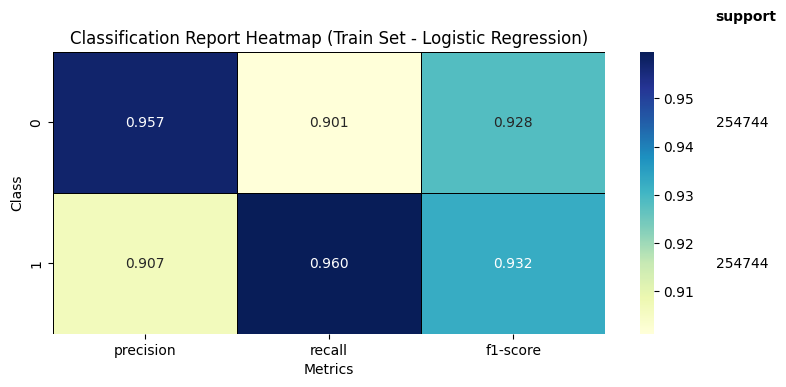

Saved Test Set - Logistic Regression plot to: classification_report_Test.png


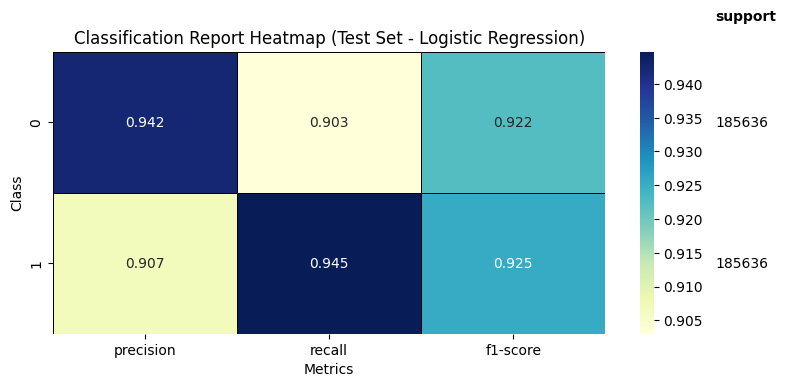

In [ ]:
# Plot 1: Train Set Classification Report
plot_classification_report(
    y_train_np,
    y_pred_train,
    'Train Set - Logistic Regression'
)

# Plot 2: Test Set Classification Report
plot_classification_report(
    y_test_np,
    y_pred,
    'Test Set - Logistic Regression'
)